# Shamela — EDA

Exploratory analysis of `datasets/shamela/*.csv` (output of `scripts/prepare_shamela.py`,
one CSV per book), ahead of building a `preprocess_shamela.py` that mirrors
`preprocessing/preprocess_sadeed_tashkeela.py`.

Columns: `filename` (book id), `output` (diacritized Arabic text),
`input` (same text with diacritics stripped).

2,695 books, ~5GB total, spread across many small files rather than one big
one (unlike Sadeed_Tashkeela). Because of that, every full-corpus statistic
below is computed in a **single combined streaming pass** over all books -
running each check as its own separate pass would multiply per-file open/
parse overhead by the number of checks, across ~2,695 files each time.

In [8]:
from collections import Counter
import hashlib
from pathlib import Path
import re
import unicodedata

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pyarabic import araby

# notebooks -> repo root
SHAMELA_DIR = Path("../datasets/shamela")
BOOK_PATHS = sorted(SHAMELA_DIR.glob("*.csv"))

CHUNKSIZE = 50_000
MISMATCH_SAMPLE_SIZE = 50

TASHKEEL = set(araby.TASHKEEL)

NON_ARABIC_RATIO_THRESHOLD = 0.3
MIN_CHARS = 3
BARE_WORD_RATIO_THRESHOLD = 0.3

HTML_TAG_RE = re.compile(r"<[^>]*>")
TATWEEL = "\u0640"
TANWIN_FATH = "\u064B"
ALEF = "\u0627"
DASH_RUN_RE = re.compile(r"-{3,}")
DIGIT_RE = re.compile(r"\d+")


def is_arabic_letter(ch):
    return "\u0600" <= ch <= "\u06FF"


def is_arabic_letter_only(ch):
    return is_arabic_letter(ch) and ch.isalpha() and ch not in TASHKEEL


print(f"{len(BOOK_PATHS):,} book CSVs found")

1,500 book CSVs found


## Single combined pass over the whole corpus

Streams every book (chunk-wise, so one huge book can't blow up memory) and
updates every accumulator below in the same loop: schema/nulls, the
`input == strip_tashkeel(input)` consistency check, length
distributions, character/diacritic vocab, per-book row counts, duplicate
detection, outlier flags, and the cleanup-step checks (HTML tags, tatweel,
tanwin order, NFC, dash runs, digits).

In [12]:
n_rows = 0
n_null = {"filename": 0, "output": 0, "input": 0}
n_empty = {"filename": 0, "output": 0, "input": 0}

n_match = 0
n_mismatch = 0
mismatches = []

char_lens = []
word_lens = []

char_freq = Counter()
diacritic_freq = Counter()

book_row_counts = {}

hash_counts = Counter()
hash_books = {}

n_no_diacritics = 0
n_non_arabic_dominant = 0
n_empty_diacritic_rows = 0
n_very_short = 0
n_high_bare_word_ratio = 0

n_html = 0
n_tatweel = 0
n_tanwin_before_alef = 0
n_tanwin_after_alef = 0
n_not_nfc = 0
n_dash_run = 0
n_digit_rows = 0

first_chunk_preview = None

for path in BOOK_PATHS:
    for chunk in pd.read_csv(
        path, chunksize=CHUNKSIZE, dtype=str, keep_default_na=False
    ):
        if first_chunk_preview is None:
            first_chunk_preview = chunk.copy()

        n_rows += len(chunk)
        book_row_counts[path.stem] = book_row_counts.get(path.stem, 0) + len(chunk)

        for col in n_null:
            n_null[col] += chunk[col].isna().sum()
            n_empty[col] += (chunk[col].fillna("").str.strip() == "").sum()

        char_lens.append(chunk["output"].str.len().to_numpy())
        word_lens.append(chunk["output"].str.split().str.len().to_numpy())

        stripped_col = chunk["output"].map(araby.strip_tashkeel)
        match = stripped_col == chunk["input"]
        n_match += match.sum()
        n_mismatch += (~match).sum()
        if len(mismatches) < MISMATCH_SAMPLE_SIZE:
            need = MISMATCH_SAMPLE_SIZE - len(mismatches)
            for _, row in chunk.loc[~match].head(need).iterrows():
                mismatches.append(
                    {
                        "book": path.stem,
                        "output": row["output"][:120],
                        "input": row["input"][:120],
                        "stripped": row["output"][:120],
                    }
                )

        char_freq.update("".join(chunk["input"]))

        for text in chunk["output"]:
            diacritic_freq.update(ch for ch in text if ch in TASHKEEL)

            h = hashlib.md5(text.encode("utf-8")).hexdigest()
            hash_counts[h] += 1
            hash_books.setdefault(h, set()).add(path.stem)

            stripped_text = text.strip()
            if not stripped_text:
                n_empty_diacritic_rows += 1
            else:
                if len(stripped_text) < MIN_CHARS:
                    n_very_short += 1
                if not any(ch in TASHKEEL for ch in text):
                    n_no_diacritics += 1
                non_arabic = sum(1 for ch in stripped_text if not is_arabic_letter(ch) and ch != " ")
                if non_arabic / len(stripped_text) > NON_ARABIC_RATIO_THRESHOLD:
                    n_non_arabic_dominant += 1

                real_words = [w for w in stripped_text.split() if any(is_arabic_letter_only(c) for c in w)]
                if real_words:
                    n_bare = sum(1 for w in real_words if not any(c in TASHKEEL for c in w))
                    if (n_bare / len(real_words)) > BARE_WORD_RATIO_THRESHOLD:
                        n_high_bare_word_ratio += 1

            if HTML_TAG_RE.search(text):
                n_html += 1
            if TATWEEL in text:
                n_tatweel += 1
            if (TANWIN_FATH + ALEF) in text:
                n_tanwin_before_alef += 1
            if (ALEF + TANWIN_FATH) in text:
                n_tanwin_after_alef += 1
            if unicodedata.normalize("NFC", text) != text:
                n_not_nfc += 1
            if DASH_RUN_RE.search(text):
                n_dash_run += 1
            if DIGIT_RE.search(text):
                n_digit_rows += 1

char_lens = np.concatenate(char_lens)
word_lens = np.concatenate(word_lens)

print(f"{n_rows:,} rows across {len(BOOK_PATHS):,} books")

5,142,347 rows across 1,500 books


## 1. Schema & sanity checks

In [13]:
print("columns:", list(first_chunk_preview.columns))
print("dtypes:\n", first_chunk_preview.dtypes)
print()
display(first_chunk_preview.head())
print()
print(f"null counts:  {n_null}")
print(f"empty counts: {n_empty}")

columns: ['filename', 'output', 'input']
dtypes:
 filename    str
output      str
input       str
dtype: object



,filename,output,input
0,10002,لَا تُحَرّكْ بِهِ لِسَانَكَ لِتَعْجَلَ بِهِ إِ...,لا تحرك به لسانك لتعجل به إن علينا جمعه وقرآنه...
1,10002,هُوَ الّذِي بَعَثَ فِي الْأُمّيّينَ رَسُولًا م...,هو الذي بعث في الأميين رسولا منهم يتلو عليهم آ...
2,10002,لَا تُحَرّكْ بِهِ لِسَانَكَ لِتَعْجَلَ بِهِ إِ...,لا تحرك به لسانك لتعجل به إن علينا جمعه وقرآنه...
3,10002,قال جل شأنه في سورة القيامة لَا تُحَرّكْ بِهِ ...,قال جل شأنه في سورة القيامة لا تحرك به لسانك ل...
4,10002,هُوَ الّذِي أَرْسَلَ رَسُولَهُ بِالْهُدَى وَدِ...,هو الذي أرسل رسوله بالهدى ودين الحق



null counts:  {'filename': np.int64(0), 'output': np.int64(0), 'input': np.int64(0)}
empty counts: {'filename': np.int64(0), 'output': np.int64(0), 'input': np.int64(0)}


## 2. Consistency check: `NON_DIACRRITIC == strip_tashkeel(DIACRRITIC)`

In [14]:
total = n_match + n_mismatch
print(f"match:    {n_match:,} ({n_match / total:.4%})")
print(f"mismatch: {n_mismatch:,} ({n_mismatch / total:.4%})")
display(pd.DataFrame(mismatches))

match:    5,142,347 (100.0000%)
mismatch: 0 (0.0000%)


""


## 3. Text length distributions

In [15]:
percentiles = [50, 90, 95, 99, 100]
char_pcts = np.percentile(char_lens, percentiles)
word_pcts = np.percentile(word_lens, percentiles)

print("char length percentiles:", dict(zip(percentiles, char_pcts.round(1))))
print("word length percentiles:", dict(zip(percentiles, word_pcts.round(1))))

char length percentiles: {50: np.float64(118.0), 90: np.float64(267.0), 95: np.float64(294.0), 99: np.float64(332.0), 100: np.float64(476.0)}
word length percentiles: {50: np.float64(15.0), 90: np.float64(34.0), 95: np.float64(37.0), 99: np.float64(40.0), 100: np.float64(40.0)}


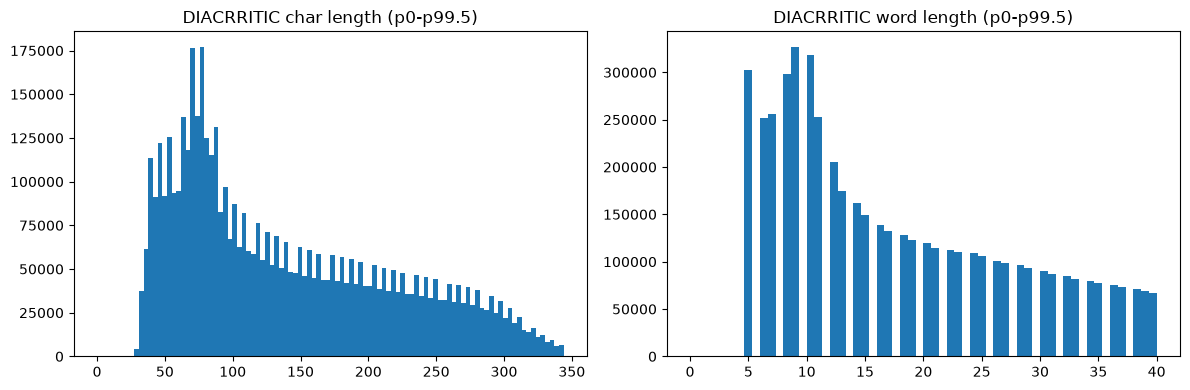

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(char_lens, bins=100, range=(0, np.percentile(char_lens, 99.5)))
axes[0].set_title("diacrritic char length (p0-p99.5)")
axes[1].hist(word_lens, bins=60, range=(0, np.percentile(word_lens, 99.5)))
axes[1].set_title("diacrritic word length (p0-p99.5)")
plt.tight_layout()
plt.show()

## 4. Character-level vocabulary

In [33]:
print(f"{len(char_freq):,} distinct characters in input")

char_freq_df = (
    pd.DataFrame(char_freq.items(), columns=["char", "count"])
    .sort_values("count", ascending=False)
    .reset_index(drop=True)
)
display(char_freq_df.sort_values(by="count", ascending=False).head(28))

103 distinct characters in input


,char,count
0,,84931265
1,ا,47937257
2,ل,41654832
3,ن,25571756
4,ي,23910288
5,م,22294906
6,و,20644088
7,ب,17651971
8,ه,15433510
9,ر,15267280


In [34]:
char_freq_df["is_arabic_range"] = char_freq_df["char"].map(is_arabic_letter)
non_arabic = char_freq_df[~char_freq_df["is_arabic_range"] & (char_freq_df["char"] != " ")]
print(f"{len(non_arabic):,} distinct non-Arabic-range characters, "
      f"{non_arabic['count'].sum():,} total occurrences")
display(non_arabic.head(40))

61 distinct non-Arabic-range characters, 1,145,275 total occurrences


,char,count,is_arabic_range
36,»,422375,False
37,«,416427,False
39,﵁,118790,False
40,﷿,43836,False
41,﵄,36688,False
42,﵀,25473,False
43,﵂,23585,False
44,﵇,23497,False
45,﵊,15070,False
46,﵎,5245,False


## 5. Diacritic mark frequency / class balance

,name,char,count
0,فتحة,َ,117154345
4,كسرة,ِ,48838086
3,سكون,ْ,45208326
1,ضمة,ُ,33562514
2,شدة,ّ,19505588
6,كسرتان,ٍ,4002242
7,ضمتان,ٌ,2372199
5,فتحتان,ً,2198038


/tmp/ipykernel_1079083/3818774613.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(diac_df["name"], rotation=45, ha="right")


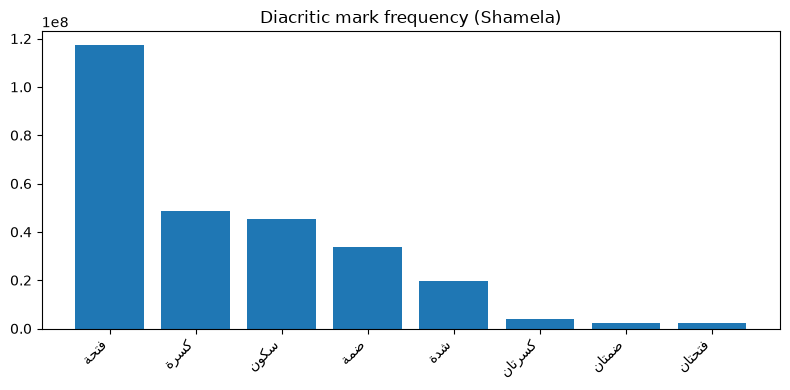

In [19]:
diac_df = pd.DataFrame(
    [(araby.name(ch, ch), ch, cnt) for ch, cnt in diacritic_freq.items()],
    columns=["name", "char", "count"],
).sort_values("count", ascending=False)
display(diac_df)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(diac_df["name"], diac_df["count"])
ax.set_xticklabels(diac_df["name"], rotation=45, ha="right")
ax.set_title("Diacritic mark frequency (Shamela)")
plt.tight_layout()
plt.show()

## 6. Book breakdown

In [20]:
book_counts_df = pd.DataFrame(
    book_row_counts.items(), columns=["book", "n_rows"]
).sort_values("n_rows", ascending=False)

print(f"{len(book_counts_df):,} books")
display(book_counts_df.describe())
display(book_counts_df.head(10))
display(book_counts_df.tail(10))

1,500 books


,n_rows
count,1500.000000
mean,3428.231333
std,7541.912246
min,200.000000
25%,373.250000
50%,999.000000
75%,3018.000000
max,106484.000000


,book,n_rows
50,10906,106484
79,11430,105764
1200,7030,82908
527,1687,80897
1473,9776,65050
343,13285,48743
1139,6157,48512
606,20762,46654
1495,9944,46445
1134,61,42571


,book,n_rows
1233,756,202
1447,96469,202
948,326,202
122,12037,202
1166,6596,202
1286,8215,202
1037,4289,202
899,30147,201
741,22876,200
474,150303,200


## 7. Duplicate detection

In [21]:
n_dup_groups = sum(1 for c in hash_counts.values() if c > 1)
n_dup_rows = sum(c for c in hash_counts.values() if c > 1)
n_cross_book_groups = sum(1 for h, c in hash_counts.items() if c > 1 and len(hash_books[h]) > 1)

print(f"{n_dup_groups:,} distinct duplicated texts, {n_dup_rows:,} rows involved "
      f"({n_dup_rows / n_rows:.2%} of corpus)")
print(f"{n_cross_book_groups:,} of those duplicate groups span more than one book "
      f"(train/val leakage risk if split by row instead of by book)")

255,832 distinct duplicated texts, 771,558 rows involved (15.00% of corpus)
205,797 of those duplicate groups span more than one book (train/val leakage risk if split by row instead of by book)


## 8. Outlier / noise detection

Same criteria as the Sadeed_Tashkeela EDA, plus an explicit check for the
"undiacritized intro + diacritized quote" pattern already spotted by hand in
one book (e.g. "قال تعالى في سورة النحل وَنَزَّلْنَا ..."): a row whose
diacritic-per-word average passes but where a large share of its *real*
(letter-containing) words carry zero diacritics.

In [22]:
print(f"fully undiacritized rows: {n_no_diacritics:,}")
print(f"non-Arabic-dominant rows (>{NON_ARABIC_RATIO_THRESHOLD:.0%}): {n_non_arabic_dominant:,}")
print(f"empty/whitespace-only rows: {n_empty_diacritic_rows:,}")
print(f"very short rows (<{MIN_CHARS} chars): {n_very_short:,}")
print(f"rows with >{BARE_WORD_RATIO_THRESHOLD:.0%} bare real words: {n_high_bare_word_ratio:,}")

fully undiacritized rows: 0
non-Arabic-dominant rows (>30%): 0
empty/whitespace-only rows: 0
very short rows (<3 chars): 0
rows with >30% bare real words: 0


## 9. Cleanup-step checks (mirroring Sadeed_Tashkeela's steps a/b/g)

Checked directly rather than assumed, since Shamela is a different source
pipeline than Sadeed_Tashkeela and may not share the same quirks.

In [23]:
print(f"rows with HTML/XML-looking tags: {n_html:,}")
print(f"rows with tatweel: {n_tatweel:,}")
print(f"tanwin-before-alef (correct order, mark on consonant): {n_tanwin_before_alef:,}")
print(f"tanwin-after-alef (wrong order): {n_tanwin_after_alef:,}")
print(f"rows not NFC-normalized: {n_not_nfc:,} ({n_not_nfc / n_rows:.1%})")
print(f"rows with a 3+ dash run: {n_dash_run:,}")
print(f"rows containing digits: {n_digit_rows:,}")

rows with HTML/XML-looking tags: 0
rows with tatweel: 0
tanwin-before-alef (correct order, mark on consonant): 1,179,081
tanwin-after-alef (wrong order): 48
rows not NFC-normalized: 10,046 (0.2%)
rows with a 3+ dash run: 0
rows containing digits: 0


## 10. Summary — parameters for `preprocess_shamela.py`

In [24]:
import json

summary = {
    "n_rows": int(n_rows),
    "n_books": len(book_counts_df),
    "consistency_match_rate": float(n_match / total),
    "char_len_p50": float(char_pcts[0]),
    "char_len_p90": float(char_pcts[1]),
    "char_len_p95": float(char_pcts[2]),
    "char_len_p99": float(char_pcts[3]),
    "word_len_p50": float(word_pcts[0]),
    "word_len_p99": float(word_pcts[3]),
    "n_distinct_chars_non_diacritic": len(char_freq),
    "n_non_arabic_range_chars": len(non_arabic),
    "diacritic_class_counts": {row["name"]: int(row["count"]) for _, row in diac_df.iterrows()},
    "n_duplicate_groups": n_dup_groups,
    "n_duplicate_rows": n_dup_rows,
    "n_cross_book_duplicate_groups": n_cross_book_groups,
    "n_fully_undiacritized_rows": n_no_diacritics,
    "n_non_arabic_dominant_rows": n_non_arabic_dominant,
    "n_empty_rows": n_empty_diacritic_rows,
    "n_very_short_rows": n_very_short,
    "n_high_bare_word_ratio_rows": n_high_bare_word_ratio,
    "n_html_tag_rows": n_html,
    "n_tatweel_rows": n_tatweel,
    "n_tanwin_before_alef": n_tanwin_before_alef,
    "n_tanwin_after_alef": n_tanwin_after_alef,
    "n_not_nfc_rows": n_not_nfc,
    "n_dash_run_rows": n_dash_run,
    "n_digit_rows": n_digit_rows,
}

print(json.dumps(summary, indent=2, ensure_ascii=False))

{
  "n_rows": 5142347,
  "n_books": 1500,
  "consistency_match_rate": 1.0,
  "char_len_p50": 118.0,
  "char_len_p90": 267.0,
  "char_len_p95": 294.0,
  "char_len_p99": 332.0,
  "word_len_p50": 15.0,
  "word_len_p99": 40.0,
  "n_distinct_chars_non_diacritic": 103,
  "n_non_arabic_range_chars": 61,
  "diacritic_class_counts": {
    "فتحة": 117154345,
    "كسرة": 48838086,
    "سكون": 45208326,
    "ضمة": 33562514,
    "شدة": 19505588,
    "كسرتان": 4002242,
    "ضمتان": 2372199,
    "فتحتان": 2198038
  },
  "n_duplicate_groups": 255832,
  "n_duplicate_rows": 771558,
  "n_cross_book_duplicate_groups": 205797,
  "n_fully_undiacritized_rows": 0,
  "n_non_arabic_dominant_rows": 0,
  "n_empty_rows": 0,
  "n_very_short_rows": 0,
  "n_high_bare_word_ratio_rows": 0,
  "n_html_tag_rows": 0,
  "n_tatweel_rows": 0,
  "n_tanwin_before_alef": 1179081,
  "n_tanwin_after_alef": 48,
  "n_not_nfc_rows": 10046,
  "n_dash_run_rows": 0,
  "n_digit_rows": 0
}
